## Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import (f_classif, SelectKBest, SelectPercentile)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from scipy import stats

In [2]:
np.random.seed(42)
n = 1000

In [3]:
# Mix of useful, weakly useful, and useless features
df = pd.DataFrame({
    # Strongly useful features
    'study_hours'     : np.random.normal(6, 2, n).clip(0, 12),
    'prev_score'      : np.random.normal(65, 15, n).clip(0, 100),
    'attendance_pct'  : np.random.normal(75, 15, n).clip(0, 100),

    # Weakly useful features
    'sleep_hours'     : np.random.normal(7, 1.5, n).clip(3, 10),
    'stress_level'    : np.random.randint(1, 10, n).astype(float),
    'exercise_days'   : np.random.randint(0, 7, n).astype(float),

    # Completely useless features (pure noise)
    'lucky_number'    : np.random.randint(1, 100, n).astype(float),
    'random_noise_1'  : np.random.normal(0, 1, n),
    'random_noise_2'  : np.random.uniform(0, 1, n),
    'student_id'      : np.arange(n).astype(float)})

In [4]:
score = (
    df['study_hours']    * 4.0 +
    df['attendance_pct'] * 0.3 +
    df['prev_score']     * 0.4 +
    df['sleep_hours']    * 1.5 +
    np.random.normal(0, 5, n))
df['result'] = (score > score.median()).astype(int)

In [5]:
df.head()

,study_hours,prev_score,attendance_pct,sleep_hours,stress_level,exercise_days,lucky_number,random_noise_1,random_noise_2,student_id,result
0,6.993428,85.990332,64.872326,4.138289,8.0,5.0,88.0,0.760506,0.654023,0.0,1
1,5.723471,78.869505,72.832220,5.709422,3.0,1.0,70.0,-1.742948,0.416217,1.0,0
2,7.295377,65.894456,63.113701,6.379592,8.0,1.0,61.0,-0.607569,0.179659,2.0,0
3,9.046060,55.295948,70.380577,9.831531,8.0,0.0,26.0,1.568182,0.689109,3.0,1
4,5.531693,75.473350,46.595780,7.834830,5.0,5.0,71.0,1.447796,0.565072,4.0,0


### Seprate the columns

In [6]:
X = df.drop('result', axis=1)
y = df['result']

In [7]:
feature_names = X.columns.tolist()
feature_names

['study_hours',
 'prev_score',
 'attendance_pct',
 'sleep_hours',
 'stress_level',
 'exercise_days',
 'lucky_number',
 'random_noise_1',
 'random_noise_2',
 'student_id']

In [8]:
print("Features:", feature_names)
print("Target distribution:", y.value_counts().to_dict())

Features: ['study_hours', 'prev_score', 'attendance_pct', 'sleep_hours', 'stress_level', 'exercise_days', 'lucky_number', 'random_noise_1', 'random_noise_2', 'student_id']
Target distribution: {1: 500, 0: 500}


# Step 1 — Calculate F-Score and P-Value Manually

In [13]:
# Calculate ANOVA F-score for each feature manually to understand what sklearn does internally

print("Manual ANOVA Calculation:\n")
print(f"{'Feature':<20} {'Mean(Fail)':>12} {'Mean(Pass)':>12} {'F-Score':>10} {'P-Value':>12} {'Useful?':>10}")
print("─" * 80)

manual_results = {}

for feature in feature_names:
    # Separate feature values by class
    fail_vals = X[feature][y == 0].values
    pass_vals = X[feature][y == 1].values

    # Calculate class means
    mean_fail = fail_vals.mean()
    mean_pass = pass_vals.mean()

    # Use scipy to compute F and p
    f_stat, p_val = stats.f_oneway(fail_vals, pass_vals)
    # f_oneway = one-way ANOVA
    # Takes the values of each group as separate arguments
    # Returns (F-statistic, p-value)

    useful = "✅ Yes" if p_val < 0.05 else "❌ No"

    manual_results[feature] = {
        'Mean_Fail': mean_fail,
        'Mean_Pass': mean_pass,
        'F_Score'  : f_stat,
        'P_Value'  : p_val}

    print(f"{feature:<20} {mean_fail:>12.3f} {mean_pass:>12.3f} "
          f"{f_stat:>10.2f} {p_val:>12.6f} {useful:>10}")

Manual ANOVA Calculation:

Feature                Mean(Fail)   Mean(Pass)    F-Score      P-Value    Useful?
────────────────────────────────────────────────────────────────────────────────
study_hours                 4.992        7.083     402.89     0.000000      ✅ Yes
prev_score                 60.999       71.027     128.85     0.000000      ✅ Yes
attendance_pct             70.632       78.948      95.30     0.000000      ✅ Yes
sleep_hours                 6.760        7.164      18.15     0.000022      ✅ Yes
stress_level                5.082        4.816       2.72     0.099371       ❌ No
exercise_days               3.014        3.060       0.13     0.718376       ❌ No
lucky_number               51.376       49.380       1.24     0.265896       ❌ No
random_noise_1             -0.070       -0.025       0.47     0.492183       ❌ No
random_noise_2              0.501        0.494       0.15     0.701666       ❌ No
student_id                491.518      507.482       0.76     0.382413  

# Step 2 — Using Sklearn's f_classif

In [14]:
# sklearn's f_classif does the same thing automatically for ALL features at once

f_scores, p_values = f_classif(X, y)
# Returns:
#   f_scores  = array of F-scores, one per feature
#   p_values  = array of p-values, one per feature

results_df = pd.DataFrame({
    'Feature'  : feature_names,
    'F_Score'  : f_scores,
    'P_Value'  : p_values,
}).sort_values('F_Score', ascending=False)

print("\nf_classif Results (sorted by F-Score):")
print(results_df.round(4).to_string(index=False))


f_classif Results (sorted by F-Score):
       Feature  F_Score  P_Value
   study_hours 402.8903   0.0000
    prev_score 128.8485   0.0000
attendance_pct  95.2999   0.0000
   sleep_hours  18.1549   0.0000
  stress_level   2.7207   0.0994
  lucky_number   1.2392   0.2659
    student_id   0.7636   0.3824
random_noise_1   0.4721   0.4922
random_noise_2   0.1468   0.7017
 exercise_days   0.1301   0.7184


# Step 3 — Visualize F-Scores


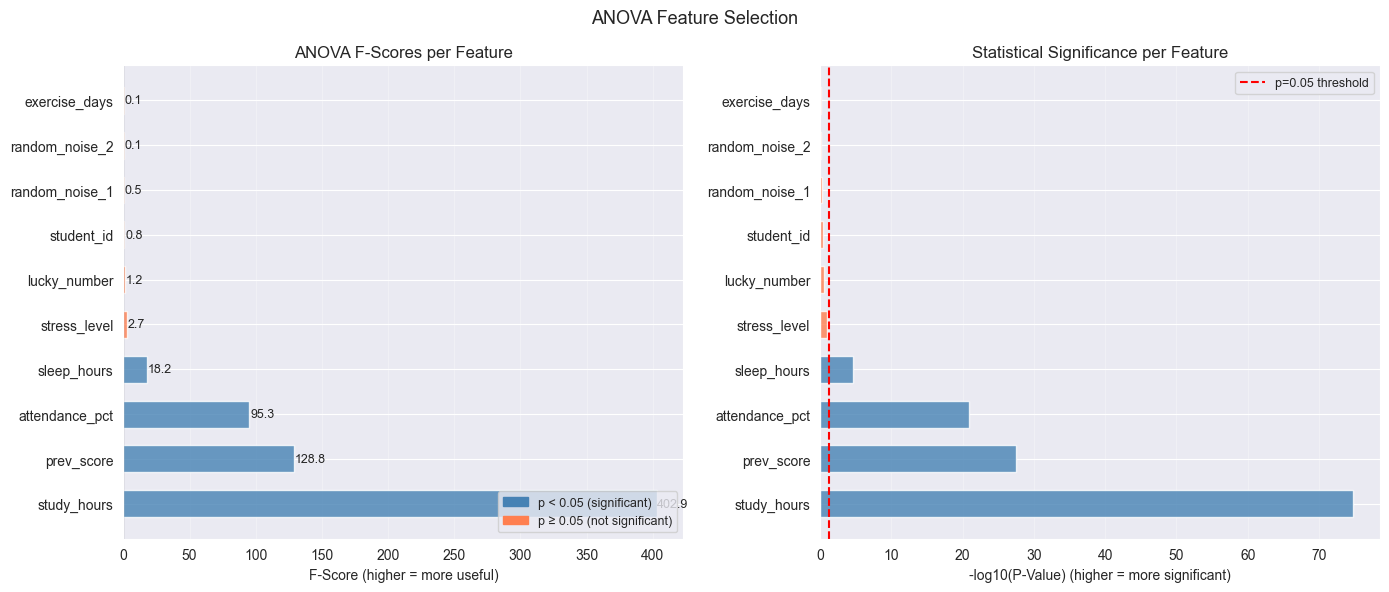

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — F-Scores (higher = more useful)
colors = ['steelblue' if p < 0.05 else 'coral' for p in results_df['P_Value']]

bars = axes[0].barh(
    results_df['Feature'],
    results_df['F_Score'],
    color  = colors,
    alpha  = 0.8,
    height = 0.6)

# Add F-score labels
for bar, val in zip(bars, results_df['F_Score']):
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}',
        va='center', fontsize=9)

axes[0].set_xlabel("F-Score (higher = more useful)")
axes[0].set_title("ANOVA F-Scores per Feature")
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='steelblue', label='p < 0.05 (significant)'),
          Patch(color='coral',     label='p ≥ 0.05 (not significant)')]
axes[0].legend(handles=legend, loc='lower right', fontsize=9)

# Plot 2 — P-Values (lower = more useful)
p_colors = ['steelblue' if p < 0.05 else 'coral'
            for p in results_df['P_Value']]

axes[1].barh(
    results_df['Feature'],
    -np.log10(results_df['P_Value'] + 1e-300),
    # ↑ -log10(p) transformation
    #   makes small p-values appear as large bars
    #   p=0.05  → -log10(0.05) = 1.30
    #   p=0.001 → -log10(0.001) = 3.0
    #   p=1e-10 → -log10(1e-10) = 10.0
    color  = p_colors,
    alpha  = 0.8,
    height = 0.6
)

# Significance threshold line
threshold = -np.log10(0.05)
axes[1].axvline(x=threshold, color='red',
                linestyle='--', linewidth=1.5,
                label='p=0.05 threshold')

axes[1].set_xlabel("-log10(P-Value) (higher = more significant)")
axes[1].set_title("Statistical Significance per Feature")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle("ANOVA Feature Selection", fontsize=13)
plt.tight_layout()
plt.show()

# Step 4 — Visualize Class Separation per Feature

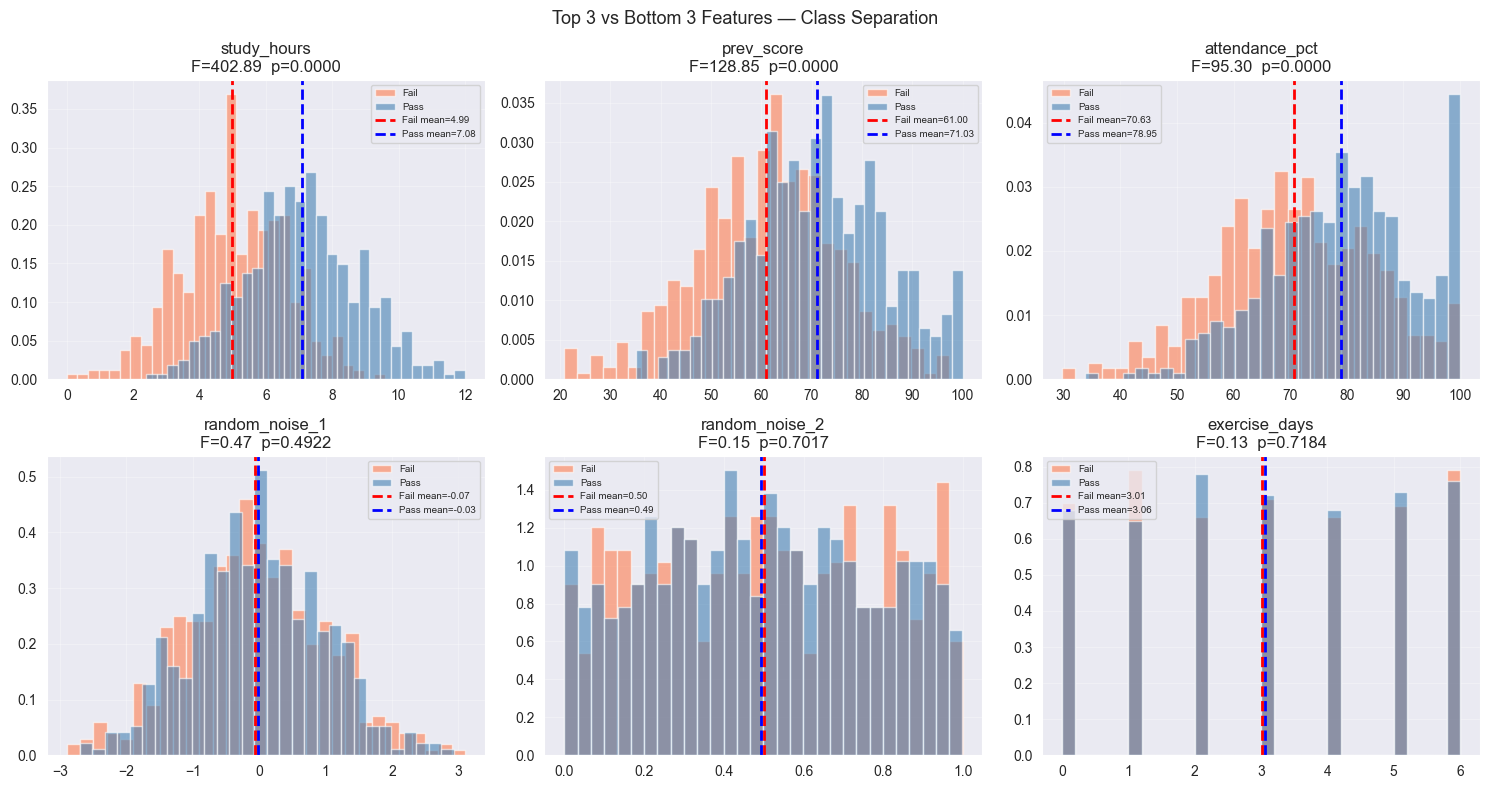

In [16]:
# Show HOW WELL each feature separates the classes using distribution plots

top_features    = results_df.head(3)['Feature'].tolist()
bottom_features = results_df.tail(3)['Feature'].tolist()
features_to_plot= top_features + bottom_features

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features_to_plot):
    fail_vals = X[feature][y == 0]
    pass_vals = X[feature][y == 1]

    # Plot distributions for each class
    ax.hist(fail_vals, bins=30, alpha=0.6,
            color='coral', label='Fail', density=True)
    ax.hist(pass_vals, bins=30, alpha=0.6,
            color='steelblue', label='Pass', density=True)

    # Mark class means
    ax.axvline(fail_vals.mean(), color='red',
               linestyle='--', linewidth=2,
               label=f'Fail mean={fail_vals.mean():.2f}')
    ax.axvline(pass_vals.mean(), color='blue',
               linestyle='--', linewidth=2,
               label=f'Pass mean={pass_vals.mean():.2f}')

    # Get F and p for this feature
    row = results_df[results_df['Feature'] == feature].iloc[0]

    ax.set_title(f"{feature}\n"
                 f"F={row['F_Score']:.2f}  "
                 f"p={row['P_Value']:.4f}")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Top 3 vs Bottom 3 Features — Class Separation",
             fontsize=13)
plt.tight_layout()
plt.show()

# Top 3: distributions should be clearly separated
# Bottom 3: distributions should heavily overlap

# Step 5 — SelectKBest (Select Top K Features)

In [17]:
# Automatically select top K features by F-score

selector_k = SelectKBest(
    score_func = f_classif,
    # ↑ use ANOVA F-score as the scoring function
    #   alternatives: chi2 (for categorical),
    #                 mutual_info_classif (non-linear)

    k          = 5
    # ↑ keep only top 5 features
    #   can also use 'all' to keep all and just rank
)

selector_k.fit(X, y)
# Internally runs f_classif on all features
# Ranks them by F-score

# Which features were selected?
selected_mask     = selector_k.get_support()
selected_features = [f for f, s in zip(feature_names, selected_mask) if s]
removed_features  = [f for f, s in zip(feature_names, selected_mask) if not s]

print("SelectKBest (K=5) Results:")
print(f"  Selected : {selected_features}")
print(f"  Removed  : {removed_features}")

# Transform data to keep only selected features
X_selected = selector_k.transform(X)
print(f"\nOriginal shape  : {X.shape}")
print(f"After selection : {X_selected.shape}")

SelectKBest (K=5) Results:
  Selected : ['study_hours', 'prev_score', 'attendance_pct', 'sleep_hours', 'stress_level']
  Removed  : ['exercise_days', 'lucky_number', 'random_noise_1', 'random_noise_2', 'student_id']

Original shape  : (1000, 10)
After selection : (1000, 5)


# Step 7 — Use in Pipeline and Compare Accuracy

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

configs = {
    'All Features (10)' : None,
    'Top 3 Features'    : 3,
    'Top 5 Features'    : 5,
    'Top 7 Features'    : 7}

print(f"\n{'Configuration':<25} {'CV Accuracy':>12} {'Std':>8}")
print("─" * 48)

for config_name, k in configs.items():

    if k is None:
        # Use all features
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model',  RandomForestClassifier(
                           n_estimators=100, random_state=42))
        ])
    else:
        # Select top K features first
        pipe = Pipeline([
            ('selector', SelectKBest(f_classif, k=k)),
            # ↑ ANOVA selection happens inside pipeline
            #   fitted on train fold only inside each CV fold
            #   prevents leakage from test into feature selection
            ('scaler',   StandardScaler()),
            ('model',    RandomForestClassifier(
                             n_estimators=100, random_state=42))
        ])

    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')

    print(f"{config_name:<25} {scores.mean():>12.4f} "
          f"{scores.std():>8.4f}")


Configuration              CV Accuracy      Std
────────────────────────────────────────────────
All Features (10)               0.8210   0.0404
Top 3 Features                  0.8270   0.0258
Top 5 Features                  0.8360   0.0449
Top 7 Features                  0.8270   0.0294


# Step 8 — Plot Threshold Effect

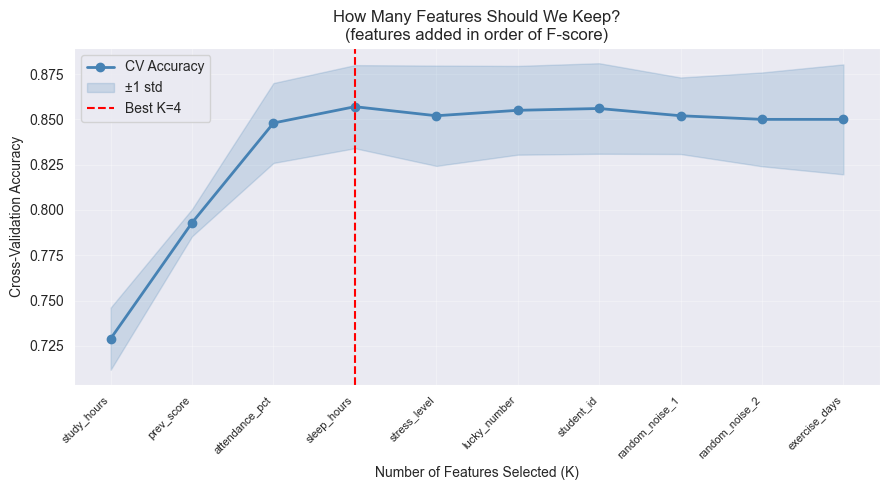

In [19]:
# How does accuracy change as we add more features
# ordered by F-score?

k_values   = list(range(1, len(feature_names) + 1))
cv_means   = []
cv_stds    = []

for k in k_values:
    pipe = Pipeline([
        ('selector', SelectKBest(f_classif, k=k)),
        ('scaler',   StandardScaler()),
        ('model',    LogisticRegression(max_iter=1000,
                                         random_state=42))
    ])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

plt.figure(figsize=(9, 5))
plt.plot(k_values, cv_means,
         marker='o', color='steelblue',
         linewidth=2, label='CV Accuracy')
plt.fill_between(k_values,
                 np.array(cv_means) - np.array(cv_stds),
                 np.array(cv_means) + np.array(cv_stds),
                 alpha=0.2, color='steelblue',
                 label='±1 std')

# Mark the elbow (where adding more features stops helping)
best_k = k_values[np.argmax(cv_means)]
plt.axvline(x=best_k, color='red', linestyle='--',
            label=f'Best K={best_k}')

plt.xlabel("Number of Features Selected (K)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("How Many Features Should We Keep?\n"
          "(features added in order of F-score)")
plt.xticks(k_values,
           [results_df['Feature'].iloc[i-1]
            if i <= len(results_df) else ''
            for i in k_values],
           rotation=45, ha='right', fontsize=8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Accuracy rises as we add useful features
# Then plateaus or drops when we add noise features
# Optimal K = where accuracy peaks